In [ ]:
# Brandon Uriel Garcia Sanchez - CatoXP


# importar librerias
import pandas as pd # manipulacion de datos
import numpy as np # calculos matemáticos
import matplotlib.pyplot as plt # graficar
import seaborn as sns # diseño y graficos
from sklearn.model_selection import train_test_split # separar el entrenamiento y el testeo
from sklearn.ensemble import RandomForestClassifier # modelo para usar random forest
from sklearn.metrics import classification_report, confusion_matrix # resume el desempeño de un modelo de clasificacion
# en este caso un random forest con valores Negativos, falsos negativos, Falsos positivos y Verdaderos positivos


df = pd.read_csv("/content/creditcard.csv") # cargar los datos
df.head(10) # show columnas

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
df.describe() # analisis descriptivo de cada una de las columnas
df.info() # verificar columnas en null
df.isnull().sum() # al detectar que no hay nulos seguimos con el analisis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# queremos detectar cuantos casos de fraudes hubo.

print(df["Class"].value_counts()) # detectamos que 2
print(df["Class"].value_counts(normalize=True)) # detectamos que el 0.998273 % son reales y 0.001727% son falsos

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [ ]:
# Separamos los fraudes en valores X y Y
x = df.drop("Class", axis=1) # todas las columnas menos "Class"
y = df["Class"] # solo colocamos la column "Class"

In [ ]:
# Dividimos los datos para que pueda aprender por su propio metodo (conjunto de entrenamiento)
# Por eso separamos los datos de x_train x_test para que no memorice los datos y no generalice los resultados

# Vamos a entrenar el detector (entrenamiento)
# Otro para probar si el detector funciona bien (test):::
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

# x variable a predecir
# y etiqueta para predecir
# test_size=0.3 # para decirle que la muestra del test sea del 30% y 70% para entrenar
# random_state=42 # parametros para que la división sea siempre igual
# stratify=y # mantiene la proporción de clases(fraude/no fraude)


In [ ]:
# En este caso desde mi punto de vista sería factible usar un Random Forest para
# detección de fraude

modelo_randomF = RandomForestClassifier(random_state=42) # crearmos el modelo
modelo_randomF.fit(x_train,y_train) # entrenamos los datos

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = modelo_randomF.predict(x_test) # hace las predicciones en una variable nueva.

# al final solamente mostramos la matriz de confusión
# es cuando me muestra cuantas predicciones fueron correctas y cualos no
print(f"\nMatriz de confusión: {confusion_matrix(y_test,y_pred)}")

# Aca solamente mostramos el reporte de clasificacion con metricas de precisión
# Solo son valores o metodos directos de la libreria scikitlearn
print(f"\nReporte de clasificación:{classification_report(y_test,y_pred)} ")
"""
Presición = Verdaderos positivos / verdaderos positivos + falsos positivos
Recall = Verdaderos positivos / verdaderos positivos + Falsos negativos #
F1-Score = 2 * precisión * recall / precisión + recall # Sirve para tener un balance
Soporte solo es el número real de casos 85295

"""



"""
output: 85290 son legitimas
        5 transacciones que clasifico como fraudes (falsos positivos)
        36 Fraudes que el modelo no detecto(Falsos negativos)
        112 fraudes detectados correctamente ( verdaderos positivos)

"""


Matriz de confusión: [[85290     5]
 [   36   112]]

Reporte de clasificación:              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443
 


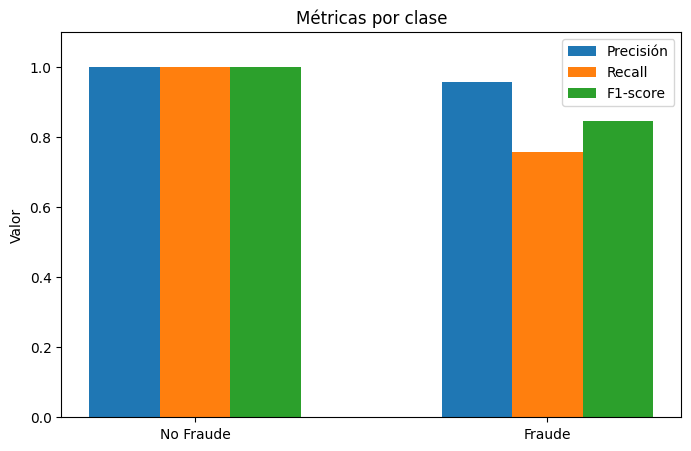

In [ ]:
# alfinal solo quiero dar una muestra gráfica de los resultados
report = classification_report(y_test, y_pred, output_dict=True)


clases = ['No Fraude', 'Fraude']

precision = [report['0']['precision'], report['1']['precision']]
recall = [report['0']['recall'], report['1']['recall']]
f1 = [report['0']['f1-score'], report['1']['f1-score']]

x = np.arange(len(clases))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, precision, width=0.2, label='Precisión')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x + 0.2, f1, width=0.2, label='F1-score')

plt.xticks(x, clases)
plt.ylim(0,1.1)
plt.ylabel('Valor')
plt.title('Métricas por clase')
plt.legend()
plt.show()

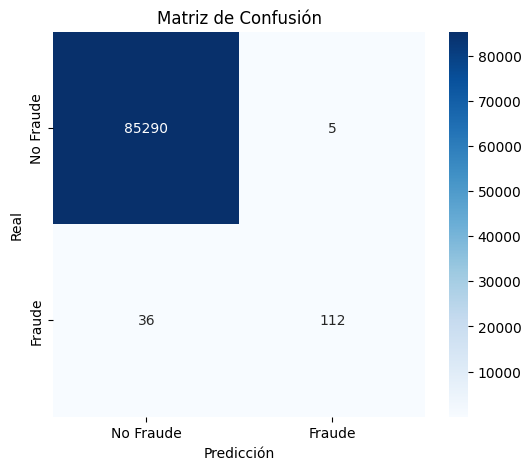

In [ ]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()